# 1. en_cz dataset creation like en_fr

In [1]:
import pandas as pd

**Load the en_cz dataset**

In [2]:
from datasets import load_dataset
data_wmt = load_dataset("zouharvi/optimal-reference-translations", 'ort_wmt')["train"]

In [3]:
#convert it to a pandas dataframe
df_en_cz_original = data_wmt.to_pandas()

**Info about the dataset:**

The dataset only has three columns **ref, systems, src.** We need only **R1 and online B** and the the source as **R1 is the postedited version of the online B sytem**. We make a central dataset as the translator dataset like en_fr experiment this way:

`'id_hal', 'Translation_id', 'line_id', 'source', 'translation','postedition'`

as there are 20 documents, we add id_hal and 'Translation_id' from 1 to 20 and for each document line_id from 1 to 8 (in the original dataset each is a segment, which mostly one sentence). And src, sys, R1 become source, translation, postedition respectively.
      

Analysis of the official WMT20 reference (REF1) revealed it was not translated "from scratch" as required by official guidelines. Using automated detection, researchers confirmed that **REF1 is a post-edited version of the ONLINE-B system.**

R1 (P1/REF1) – Post-edited MT: Created by an agency using ONLINE-B as a base. High quality, but structurally biased toward the MT system.



**add 'id_hal', 'Translation_id', 'line_id' to each line/ sentences**

In [4]:
#As each document contains 8 source sentences, and there are 20 documents, we add line numbers from 1 to 8 
#and document and id_hal number from 1 to 20 inclusive.

df_en_cz_original["id_hal"] = df_en_cz_original.index // 8 + 1 # document id
df_en_cz_original["Translation_id"] = df_en_cz_original.index // 8 + 1 # document id
df_en_cz_original["line_id"] = df_en_cz_original.index % 8 + 1

**Save the df_en_cz_original as *df_en_cz_original_with_id_numbers***

This will allow us to trace back and get all the references for each source, helpful when calculating automatic metric scores like BLEU.

In [5]:
df_en_cz_original.to_csv("df_en_cz_original_with_id_numbers", index=False)

**Build the dataset like en_fr exp**

now we need only the Ref1/R1, online B from systems and the source. "Online-B.1589" has this structure: { "Online-B.1589": { "tgt": "Kmenové buňky 56 pacientů...", "score": -0.4510520479 } }

so we need to extract the tgt key in our new dataset

In [6]:
# Create new dataframe
new_df = df_en_cz_original[["ref", "systems", "src", "id_hal","Translation_id", "line_id"]].copy()

# Extract R1 from ref
new_df["ref"] = df_en_cz_original["ref"].apply(
    lambda x: x["R1"]
)

# Extract tgt from online-B
new_df["sys"] = df_en_cz_original["systems"].apply(
    lambda x: x["Online-B.1589"]["tgt"]
)

# Keep only the columns we want
new_df = new_df[
    ["ref", "sys", "src","id_hal","Translation_id", "line_id"]
]

# Display
print(new_df.head())



                                                 ref  \
0  Vláda přikázala odchod do důchodu dalším 15 da...   
1  Ústřední rada nepřímých daní a cel (CBIC) – ag...   
2  Od června je to už počtvrté, co jsou zkorumpov...   
3  Podle oficiálních zdrojů proběhla akce v návaz...   
4  „Nedávno jsme podnikli odvážný krok, když jsme...   

                                                 sys  \
0  Vláda povinně odešla do důchodu dalších 15 daň...   
1  Ústřední rada nepřímých daní a cel (CBIC) - ag...   
2  Od června je to čtvrté kolo vyhození zkorumpov...   
3  Zdroj uvedl, že akce byla v souladu s adresou ...   
4  "Nedávno jsme podnikli odvážný krok povinného ...   

                                                 src  id_hal  Translation_id  \
0  The government has compulsorily retired 15 mor...       1               1   
1  The Central Board of Indirect Taxes and Custom...       1               1   
2  Since June, this is the fourth round of sackin...       1               1   
3  Sou

**Reorder the columns and change column names to match en_fr  dataset**

In [7]:
new_df = new_df.rename(columns={"src": "source", "sys": "translation", "ref": "postedition"})
df_en_cz_final = new_df[['id_hal', 'Translation_id', 'line_id', 'source', 'translation', 'postedition']]

In [8]:
df_en_cz_final.head(10)

,id_hal,Translation_id,line_id,source,translation,postedition
0,1,1,1,The government has compulsorily retired 15 mor...,Vláda povinně odešla do důchodu dalších 15 daň...,Vláda přikázala odchod do důchodu dalším 15 da...
1,1,1,2,The Central Board of Indirect Taxes and Custom...,Ústřední rada nepřímých daní a cel (CBIC) - ag...,Ústřední rada nepřímých daní a cel (CBIC) – ag...
2,1,1,3,"Since June, this is the fourth round of sackin...",Od června je to čtvrté kolo vyhození zkorumpov...,"Od června je to už počtvrté, co jsou zkorumpov..."
3,1,1,4,Sources said the action was in line with Prime...,"Zdroj uvedl, že akce byla v souladu s adresou ...",Podle oficiálních zdrojů proběhla akce v návaz...
4,1,1,5,"""We have recently taken the bold step of compu...","""Nedávno jsme podnikli odvážný krok povinného ...","„Nedávno jsme podnikli odvážný krok, když jsme..."
5,1,1,6,Nearly half of the officials retired were thos...,"Téměř polovina úředníků v důchodu byli ti, kte...","Téměř polovina úředníků, kteří odešli do důcho..."
6,1,1,7,"In June, the government had compulsorily retir...",V červnu vláda povinně odešla do důchodu 15 úř...,V červnu vláda donutila odejít do důchodu 15 ú...
7,1,1,8,"In August, the government compulsorily retired...",V srpnu vláda povinně odešla do důchodu 22 úře...,V srpnu vláda poslala do důchodu 22 úředníků C...
8,2,2,1,A woman in Maine got 500 letters from United H...,Žena v Maine dostala 500 dopisů od United Heal...,Žena v Maine obdržela během pěti dnů 500 dopis...
9,2,2,2,Stephanie Lay said she found the piles of lett...,"Stephanie Lay uvedla, že ve čtvrtek a pondělí ...","Stephanie Layová uvedla, že během čtvrtka a po..."


**Save the final dataset to work with for en_cz**

In [9]:
df_en_cz_final.to_csv("df_en_cz_final.csv", index=False)

#### end of step 1.

# 2. Make the same datasets as en_fr

**load the df_en_cz_final.csv file**

In [13]:
post_edit_file = "./df_en_cz_final.csv"

In [14]:
import pandas as pd
df = pd.read_csv(post_edit_file)

# Display the first 5 rows
print(df.head(10))


   id_hal  Translation_id  line_id  \
0       1               1        1   
1       1               1        2   
2       1               1        3   
3       1               1        4   
4       1               1        5   
5       1               1        6   
6       1               1        7   
7       1               1        8   
8       2               2        1   
9       2               2        2   

                                              source  \
0  The government has compulsorily retired 15 mor...   
1  The Central Board of Indirect Taxes and Custom...   
2  Since June, this is the fourth round of sackin...   
3  Sources said the action was in line with Prime...   
4  "We have recently taken the bold step of compu...   
5  Nearly half of the officials retired were thos...   
6  In June, the government had compulsorily retir...   
7  In August, the government compulsorily retired...   
8  A woman in Maine got 500 letters from United H...   
9  Stephanie Lay said

**Only keep 8 documents that we have selected based on the character length**

[3, 5, 6, 7, 13, 17, 18, 19] - document number / Translation_id

[1785, 1575, 1367, 1625, 1525, 1472, 1523, 1356] / doc lengths

In [15]:
selected_ids = [3, 5, 6, 7, 13, 17, 18, 19]
df = df[df["Translation_id"].isin(selected_ids)]


In [18]:
df = df.reset_index(drop=True)


**now save the final dataset with the selected 8 docs**

In [22]:
#save the final dataset with 8 docs
df.to_csv("df_en_cz_final_with_selected_8_docs.csv", index=False)

**Load the XCOMET-XL model and initialize it with custom class**

In [23]:
import pandas as pd
df = pd.read_csv("./df_en_cz_final_with_selected_8_docs.csv")

# Display the first 5 rows
print(df.head(10))

   id_hal  Translation_id  line_id  \
0       3               3        1   
1       3               3        2   
2       3               3        3   
3       3               3        4   
4       3               3        5   
5       3               3        6   
6       3               3        7   
7       3               3        8   
8       5               5        1   
9       5               5        2   

                                              source  \
0  Using data and artificial intelligence to try ...   
1  "It's one of the first commercial uses of inve...   
2  HSBC declined to comment on how much it expect...   
3  The drive is an important part of the bank's e...   
4  HSBC was forced to invest hundreds of millions...   
5  The system works by mapping individual custome...   
6  That system has already freed up more than 400...   
7  HSBC's Nivison said the lightbulb moment was r...   
8  Stem cells of 56 child cancer patients lost at...   
9  A freezer malfunct

In [9]:
# load the xcomet custom class and initialize it with xcomet model
#These lines allow the file to load the COMET_GR model - starts here
import sys
from pathlib import Path

COMET_GR = Path.cwd().parent
sys.path.insert(0, str(COMET_GR))
#These lines allow the file to load the COMET_GR model - ends here

# load the custom class without initializing it.
from comet import download_model, load_from_checkpoint
from comet.models.multitask.unified_metric import UnifiedMetric

class CustomXCOMET(UnifiedMetric):
    print("custom unified_metric")

    
#these checks if we loaded the correct COMET codes and where it is located and are we getting 
#the unified_metric class correctly. 
import comet

print("COMET:", comet.__file__)
print("UnifiedMetric:", UnifiedMetric.__module__)

# here it download the model and load it from the downloaded checkpoint
from comet import download_model, load_from_checkpoint

model_path = download_model("Unbabel/XCOMET-XL")

# Here we are initializing the custom class using the loaded checkpoint, so the model is downloaded and
#it will get initialized using the custom class.
model = CustomXCOMET.load_from_checkpoint(model_path,strict = False)

custom unified_metric
COMET: /auto/brno2/brno2/rahmang/xcomet/arafat_comet/COMET_GR/comet/__init__.py
UnifiedMetric: comet.models.multitask.unified_metric


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Encoder model frozen.
/storage/brno2/home/rahmang/envs/xcomet/lib/python3.11/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


### create data list for calculating the spans without the ref

data = [List[dict]]

In [24]:
# # Iterate and extract values from two columns
data = []
count = 0
for index, row in df.iterrows():
    source      = row['source']
    translation = row['translation']
   
    data.append({
        "src": source,
        "mt" : translation,
    })
   

#### call the model on the data to get the spans

In [27]:
model_output = model.predict(data, batch_size=8, gpus=1)

/storage/brno2/home/rahmang/envs/xcomet/lib/python3.11/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [GPU-c2fdbbed-04db-983b-736f-f94dbfeab8f1]
/storage/brno2/home/rahmang/envs/xcomet/lib/python3.11/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that e

In [28]:
# Segment-level scores
print (len(model_output.scores))


64


In [29]:
# Score explanation (error spans)
print (model_output.metadata.error_spans[1])

[{'text': ['do'], 'confidence': 0.3504355847835541, 'severity': 'major', 'start': 42, 'end': 45, 'check severity': ['major']}, {'text': ['podnikání,'], 'confidence': 0.5043115615844727, 'severity': 'major', 'start': 77, 'end': 88, 'check severity': ['major']}, {'text': ['je'], 'confidence': 0.41571885347366333, 'severity': 'major', 'start': 120, 'end': 123, 'check severity': ['major']}, {'text': ['podstaty', 'nižší', 'riziko', 'a', 'rychlejší', 'vítězství,“'], 'confidence': 0.4437088072299957, 'severity': 'major', 'start': 130, 'end': 176, 'check severity': ['major', 'major', 'major', 'major', 'major', 'major', 'major']}, {'text': ['vedoucí', 'klientského', 'bankovnictví'], 'confidence': 0.43836647272109985, 'severity': 'major', 'start': 206, 'end': 239, 'check severity': ['major', 'major', 'major', 'major', 'major', 'major']}]


**check the span count by documents**

In [30]:
number_of_spans_list = []
for line in model_output.metadata.error_spans:
    number_of_spans = 0
    for span in line:
        number_of_spans += len(span['text'])
    number_of_spans_list.append(number_of_spans)

In [31]:
# now calculate total number of spans in each doc
spans_per_doc = [sum(number_of_spans_list[i:i+8]) for i in range(0, len(number_of_spans_list), 8)]

In [32]:
spans_per_doc

[73, 59, 41, 32, 90, 74, 42, 25]

**now save the the spans by xcomet for the df_en_cz_final_with_selected_8_docs**

In [33]:
# create a json file with the results
import json

# Save to a JSON file
#same as "output_all_spans_translator.json"
with open("output_all_spans_df_en_cz_final_with_selected_8_docs.json", "w", encoding="utf-8") as f:
    json.dump(model_output.metadata.error_spans, f, ensure_ascii=False, indent=2)  # `indent` for readability

In [1]:
# Read the JSON file
import json

with open("output_all_spans_df_en_cz_final_with_selected_8_docs.json", "r", encoding="utf-8") as f:
    loaded_data_all_spans = json.load(f)

In [2]:
loaded_data_all_spans[1]

[{'text': ['do'],
  'confidence': 0.3504355847835541,
  'severity': 'major',
  'start': 42,
  'end': 45,
  'check severity': ['major']},
 {'text': ['podnikání,'],
  'confidence': 0.5043115615844727,
  'severity': 'major',
  'start': 77,
  'end': 88,
  'check severity': ['major']},
 {'text': ['je'],
  'confidence': 0.41571885347366333,
  'severity': 'major',
  'start': 120,
  'end': 123,
  'check severity': ['major']},
 {'text': ['podstaty', 'nižší', 'riziko', 'a', 'rychlejší', 'vítězství,“'],
  'confidence': 0.4437088072299957,
  'severity': 'major',
  'start': 130,
  'end': 176,
  'check severity': ['major',
   'major',
   'major',
   'major',
   'major',
   'major',
   'major']},
 {'text': ['vedoucí', 'klientského', 'bankovnictví'],
  'confidence': 0.43836647272109985,
  'severity': 'major',
  'start': 206,
  'end': 239,
  'check severity': ['major', 'major', 'major', 'major', 'major', 'major']}]

In [3]:
from collections import Counter


# Flatten and count all 'check severity' values
severity_counter = {'minor': 0, 'major': 0, 'critical': 0}
for sentence in loaded_data_all_spans:
    for i, spans in enumerate(sentence):
        if spans["severity"] == "minor":
            severity_counter["minor"] += len(spans["text"])
        elif spans["severity"] == "major":
            severity_counter["major"] += len(spans["text"])
        elif spans["severity"] == "critical":
            severity_counter["critical"] += len(spans["text"])

In [4]:
severity_counter

{'minor': 67, 'major': 306, 'critical': 63}

In [5]:
print(sum(severity_counter.values()))

436


In [6]:
total_operations_by_pe = 0 # this is the number of insertions/deletions/replace
total_number_of_insertions_global = 0
insertions_inside_spans_global = 0
insertions_outside_spans_global = 0 
insertions_inside_spans_global_severity = {
    
                                            "minor":0,
                                            "major":0,
                                            "critical":0
                                          } 
insertions_inside_spans_words_index_global = []# store sentence number,index as the tuple
severity_tp = {} # store all the words from minor, major and critical ( these will be the keys and the
# words will be the values
severity_fp = {"minor":0,
                "major":0,
                "critical":0} # store all the words from minor, major and critical ( these will be the keys and the
# words will be the values
ok_count_global = 0
replace_count_global = 0
delete_count_global = 0
minors = 0
majors = 0
criticals = 0
tp = 0
fp = 0
fn = 0

In [7]:
### load the dataset
import pandas as pd
df = pd.read_csv("./df_en_cz_final_with_selected_8_docs.csv")


# tokenize the translation and postedition using xcomet's tokenizer


In [10]:
# load the tokenizer
tokenizer = model.encoder.tokenizer


def tokenize_with_offsets(text):
    """Tokenize text and return (words, offsets)"""
    tokenized = tokenizer(
        text,
        return_offsets_mapping=True,
        return_tensors="pt",
        truncation=True
    )
    
    word_ids = tokenized.word_ids()
    offset_mapping = tokenized["offset_mapping"][0].tolist()
    
    word_to_data = {}
    for idx, (word_id, (start, end)) in enumerate(zip(word_ids, offset_mapping)):
        if word_id is None:
            continue
        if word_id not in word_to_data:
            word_to_data[word_id] = {
                "tokens": [],
                "start": start,
                "end": end
            }
        else:
            word_to_data[word_id]["end"] = end
        token = tokenizer.convert_ids_to_tokens(tokenized["input_ids"][0][idx].item())
        word_to_data[word_id]["tokens"].append(token)
    
    word_mapping = []
    word_offsets = []
    for word_id in sorted(word_to_data.keys()):
        data = word_to_data[word_id]
        word = tokenizer.convert_tokens_to_string(data["tokens"]).strip()
        word_mapping.append(word)
        word_offsets.append((data["start"], data["end"]))
    
    return word_mapping, word_offsets

# Process DataFrame
def process_row(row):
    # Process translation
    trans_text = row["translation"][0] if isinstance(row["translation"], list) else row["translation"]
    trans_tokens, trans_offsets = tokenize_with_offsets(trans_text)
    
    # Process postedition
    post_text = row["postedition"][0] if isinstance(row["postedition"], list) else row["postedition"]
    post_tokens, post_offsets = tokenize_with_offsets(post_text)
    
    return pd.Series({
        "translation_tokenized": trans_tokens,
        "translation_word_offset": trans_offsets,
        "postedition_tokenized": post_tokens,
        "postedition_word_offset": post_offsets
    })

# Apply to DataFrame
new_cols = df.apply(process_row, axis=1)
df = pd.concat([df, new_cols], axis=1)

# Show results
print(df[["translation_tokenized", "translation_word_offset", 
          "postedition_tokenized", "postedition_word_offset"]].head())

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


                               translation_tokenized  \
0  [Využití, dat, a, umělé, inteligence, k, vyzko...   
1  [„Je, to, jedno, z, prvních, komerčních, inves...   
2  [HSBC, se, odmítla, vyjádřit, k, tomu,, co, oč...   
3  [Pohon, je, důležitou, součástí, úsilí, banky,...   
4  [HSBC, byla, nucena, investovat, stovky, milio...   

                             translation_word_offset  \
0  [(0, 7), (7, 11), (11, 13), (13, 19), (19, 31)...   
1  [(0, 3), (3, 6), (6, 12), (12, 14), (14, 22), ...   
2  [(0, 4), (4, 7), (7, 15), (15, 24), (24, 26), ...   
3  [(0, 5), (5, 8), (8, 18), (18, 27), (27, 33), ...   
4  [(0, 4), (4, 9), (9, 16), (16, 27), (27, 34), ...   

                               postedition_tokenized  \
0  [Využití, dat, a, umělé, inteligence, ke, zvýš...   
1  [„Je, to, jedna, z, prvních, komerčních, inves...   
2  [HSBC, se, odmítla, vyjádřit, k, tomu,, co, oč...   
3  [Kampaň, je, důležitou, součástí, úsilí, banky...   
4  [HSBC, byla, nucena, investovat, stovky, mi

In [11]:
#save the df as a csv file
#same as postedition_aligned_with_tokenized_offsets_translator.csv
df.to_csv("postedition_aligned_with_tokenized_offsets_df_en_cz_final_with_selected_8_docs.csv", index=False)


### difflib helper function


In [13]:
#mapping between tokenized words and raw indices
def split_with_indice(text):
    words = []
    current_position = 0
    n = len(text)
    while current_position < n:
        # Skip leading spaces
        while current_position < n and text[current_position] == ' ':
            current_position += 1
        if current_position >= n:
            break
        start = current_position
        # Find end of word
        while current_position < n and text[current_position] != ' ':
            current_position += 1
        end = current_position  # Last character index of the word
        words.append((text[start:end+1], start, end))
    return words

In [18]:
# get the relevant words and mapping to show if inside a span, the changes doney by the post editors
# yielded any less or more words in the post edited sentence- utility function
def mapping_get_the_relevant_words(index,words1, words2,i1, i2, j1, j2):
    replaced_words1 = words1[i1:i2]
    replaced_words2 = words2[j1:j2]
    changes = []
    # if index == 5:
    #     print("replaced_words1: ",replaced_words1)
    #     print("replaced_words2: ", replaced_words2)
    # Pair words (even if replacement lengths differ)
    max_len = max(len(replaced_words1), len(replaced_words2))
    for idx in range(max_len):
        word1 = replaced_words1[idx] if idx < len(replaced_words1) else None
        word2 = replaced_words2[idx] if idx < len(replaced_words2) else None
        changes.append((word1, word2))
    # if index == 5:
    #     print("changes: ", changes)
    return changes

In [19]:
total_insertions_from_opcodes = 0

In [20]:
def get_first_offset_of_last_word_of_a_span(insertion_index,span_last_offset, mt_offsets):
    first_offset_of_last_word_of_a_span = 0
    for i in range(insertion_index, len(mt_offsets)):
        word_offsets = mt_offsets[i]
        #print(f"i is: {i} and mt_offsets[i] is: {mt_offsets[i]}")
        if word_offsets[1] == span_last_offset:
            #print("word_offsets[0]: ", word_offsets[0])
            first_offset_of_last_word_of_a_span = word_offsets[0]
            break
    return first_offset_of_last_word_of_a_span

In [21]:
from difflib import SequenceMatcher

def find_word_replacements(index, mt_tokens, pet_tokens,mt_offsets,pet_offsets, error_spans_indexes,words_in_the_spans, spans_each_mt):
    # Tokenize into words
    words1 = mt_tokens
    words2 = pet_tokens
   
    matcher = SequenceMatcher(None, words1, words2)
    opcodes = matcher.get_opcodes()
    
    ok_count = 0 
    replace_count = 0 
    delete_count = 0 
    insertions_inside_spans = 0 
    insertions_outside_spans = 0 
    total_number_of_insertions = 0 
    insertions_inside_spans_severity = {}
    insertions_inside_spans_words_index = []
    mapping = [] 
    relevant_words = []
    insertions = []
    not_relevant_words = []
    total_insertions_from_opcodes = 0
    for tag, i1, i2, j1, j2 in opcodes:
            if tag == "replace":
            # Extract replaced(any replace/insertion/deletions) words
                replacements = mapping_get_the_relevant_words(index,words1, words2,i1, i2, j1, j2)
                # relevant_words.extend([t[0] for t in replacements if t[0] is not None])
                relevant_words.extend(words1[i1:i2])
            elif tag == "delete":
                replacements = mapping_get_the_relevant_words(index,words1, words2,i1, i2, j1, j2)
                #print("mapping for delete: ", replacements)
                # relevant_words.extend([t[0] for t in replacements if t[0] is not None])
                relevant_words.extend(words1[i1:i2])
            elif tag == "insert":
                replacements = mapping_get_the_relevant_words(index,words1, words2,i1, i2, j1, j2)
                
                total_insertions_from_opcodes += j2 - j1
                
                insertions.append(("insertion",index, i1, i2, [t[1] for t in replacements if t[0] is not None]))
            else:
                #print("i am here else tag")
                replacements = mapping_get_the_relevant_words(index,words1, words2,i1, i2, j1, j2)
                not_relevant_words.extend([t[0] for t in replacements])
            mapping.append((tag, replacements))

            if tag == "equal":
                ok_count += i2 - i1 # not relevant words as they were not edited by the post editors
           
            elif tag == "insert":
                if i1 >= len(words1) or (i1 == 0 and i2==0): 
                    # (insert,0,0, 0,2)
                    insertions_outside_spans += j2 - j1
                    total_number_of_insertions += j2 - j1
                    # insertions_outside_spans_severity calculation
                    continue
    
                insertion_span = mt_offsets[i1][0]
                #print("offset of the insertion_span: ", insertion_span)

                in_span_insertion = False
                for spans_index in error_spans_indexes:
                    severity = spans_index[0]
                    #get_first_offset_of_second_last_word_of_a_span
                    #print("the value of i1 is: ", i1)
                    first_offset_of_last_word_of_a_span = get_first_offset_of_last_word_of_a_span(i1,spans_index[2], mt_offsets)
                    
                    #print("spans_index[0] :", spans_index[0] , "and insertion_span[0]: ",insertion_span[0] )
                    #if insertion_span <= 
                    if  insertion_span >= spans_index[1]   and insertion_span <= first_offset_of_last_word_of_a_span:
                       in_span_insertion = True
                       #print("in span insertion is true and the insertion_span first offset is: ", insertion_span)
                       
                       if severity in insertions_inside_spans_severity:
                           insertions_inside_spans_severity[severity] += j2 - j1  
                       else:
                           insertions_inside_spans_severity[severity] = j2-j1
                       insertions_inside_spans_words_index.append((index,i1,i2))
                       break
                if in_span_insertion:
                    insertions_inside_spans += j2 - j1
                    #print("insertions_inside_spans: ", insertions_inside_spans)
                else:
                    insertions_outside_spans += j2 - j1
                    
                total_number_of_insertions += j2 - j1
            elif tag == "replace":
                
                replace_count += i2-i1
            elif tag == "delete":
                delete_count += i2- i1
                                
    
    return opcodes, total_insertions_from_opcodes,mapping,opcodes, ok_count, replace_count, delete_count,insertions_inside_spans,insertions_outside_spans,total_number_of_insertions,relevant_words,not_relevant_words, insertions_inside_spans_severity, insertions_inside_spans_words_index


In [22]:
relevant_words_global = []
not_relevant_words_global = []
statistics_results_json = []
import copy
relevant_words_global_count = 0

In [23]:
# iterate through the aligned postedition df
for index, row in df.iterrows():
    # get the severity counts and create the words_in_the_spans list containing all the words in
    #the spans
    words_in_the_spans = {}
    spans_each_mt = copy.deepcopy(loaded_data_all_spans[index])  # Create an independent copy
    
    error_spans_indexes = []
    for i, span in enumerate(spans_each_mt):
        if span['severity'] == "minor":
            minors += len(span['text'])
            if "minor" in words_in_the_spans:
                words_in_the_spans["minor"].extend(span["text"].copy())
            else:
                words_in_the_spans["minor"] = span["text"].copy()
        elif span['severity'] == "major":
            majors += len(span['text'])
            if "major" in words_in_the_spans:
                words_in_the_spans["major"].extend(span["text"].copy())
            else:
                words_in_the_spans["major"] = span["text"].copy()
        elif span['severity'] == "critical":
            criticals += len(span['text'])
            if "critical" in words_in_the_spans:
                words_in_the_spans["critical"].extend(span["text"].copy())
            else:
                words_in_the_spans["critical"] = span["text"].copy()
        
        
        error_spans_indexes.append((span['severity'],span['start'], span['end']))
    ok = len(words_in_the_spans) - (minors + majors + criticals)
    # use difflib
    mt_tokens = row['translation_tokenized']
    pet_tokens  = row['postedition_tokenized']
    mt_offsets  = row['translation_word_offset']
    pet_offsets = row['postedition_word_offset']
    opcodes, total_insertions_opcodes, difflib_result,opcodes, ok_count, replace_count, delete_count,insertions_inside_spans,insertions_outside_spans,total_number_of_insertions,relevant_words, not_relevant_words,insertions_inside_spans_severity, insertions_inside_spans_words_index = find_word_replacements(index, mt_tokens, pet_tokens,mt_offsets,pet_offsets, error_spans_indexes,words_in_the_spans,spans_each_mt)
   
    total_insertions_from_opcodes += total_insertions_opcodes
    total_number_of_insertions_global += total_number_of_insertions
    insertions_inside_spans_global += insertions_inside_spans
    insertions_outside_spans_global += insertions_outside_spans
    ok_count_global += ok_count
    replace_count_global += replace_count
    delete_count_global += delete_count
    
    for word in relevant_words:
        if word == None:
            print("it is none")
            relevant_words.remove(word)
            #print("relevant words: ", relevant_words)
    relevant_words_copy = relevant_words.copy()
    relevant_words_global.append(relevant_words.copy())
    relevant_words_global_count += len(relevant_words)
    
    # Update global severity counts
    for key, value in insertions_inside_spans_severity.items():
        insertions_inside_spans_global_severity[key] += value  # assumes key is one of the three

    # Extend global list with new tuples
    insertions_inside_spans_words_index_global.extend(insertions_inside_spans_words_index)
    
    
    # get relevant, not relevant words and insertions count from difflib result
     
    for severity, words in words_in_the_spans.items():
        for word in list(words):
            if word in relevant_words:
                tp += 1
                if severity in severity_tp:
                    severity_tp[severity] +=1
                else:
                    severity_tp[severity] =1
                words.remove(word)
                relevant_words.remove(word)
    
    for severity, words in words_in_the_spans.items():
        
        if severity == "minor":
            severity_fp[severity] += len(words)           
            fp += len(words)
        elif severity == "major":
            severity_fp[severity] += len(words)
            fp += len(words)
        else:
            severity_fp["critical"] += len(words)
            fp += len(words)
        
    
    fn += len(relevant_words)
   
    #write the json file
    
    entry = {
        "index": index + 1,  # Index starts at 1 instead of 0
        "source": row['source'],
        "translation": row['translation'],
        "postedition": row['postedition'],
        "relevant_words": relevant_words_copy,
        "difflib operations": copy.deepcopy(opcodes),
        
        "spans_each_mt": copy.deepcopy(spans_each_mt)
       
    }
    
    # Append the entry to the list
    statistics_results_json.append(entry)

  
    

In [24]:
statistics_results_json[3]

{'index': 4,
 'source': "The drive is an important part of the bank's efforts to defend its global presence at a time when some analysts and investors are saying it should shrink or exit markets like the United States where it makes returns below its cost of capital.",
 'translation': 'Pohon je důležitou součástí úsilí banky bránit svou globální přítomnost v době, kdy někteří analytici a investoři říkají, že by měla zmenšovat nebo opouštět trhy, jako jsou Spojené státy, kde dosahuje návratnosti pod náklady na kapitál.',
 'postedition': 'Kampaň je důležitou součástí úsilí banky obhájit své globální postavení v době, ve které někteří analytici a investoři říkají, že by měla zmenšovat nebo opouštět trhy, jako jsou Spojené státy, na kterých dosahuje nižší návratnosti, než jsou náklady na kapitál.',
 'relevant_words': ['Pohon',
  'bránit',
  'svou',
  'přítomnost',
  'kdy',
  'kde',
  'návratnosti',
  'pod'],
 'difflib operations': [('replace', 0, 1, 0, 1),
  ('equal', 1, 6, 1, 6),
  ('repl

In [25]:
#statistics_results_json
# Save the entire list to a single JSON file
#same as all_entries_with_opcodes_translator.json
with open("all_entries_with_opcodes_df_en_cz_final_with_selected_8_docs.json", "w", encoding="utf-8") as f:
    json.dump(statistics_results_json, f, ensure_ascii=False, indent=4)  # Format for readability

In [26]:
print(total_number_of_insertions_global)
print(insertions_inside_spans_global)
print(insertions_outside_spans_global)

64
23
41


In [27]:
total_insertions_from_opcodes

64

In [28]:
print(ok_count_global)
print(replace_count_global)
print(delete_count_global)
print("total: ", ok_count_global + replace_count_global + delete_count_global)

1248
576
45
total:  1869


In [29]:
tn = ok_count_global-fp
tn

1058

In [30]:
print("tp: ",tp)
print("fp: ", fp)
print("fn: ", fn)
# print("tn: ", tn)
print("total: ", tp+ fp + fn + tn)

tp:  246
fp:  190
fn:  375
total:  1869


In [31]:
relevant_words_global_count

621

In [32]:
len(relevant_words_global)

64

In [33]:
relevant_words_global[1]

['jedno', 'je', 'ze', 'podstaty', 'globální', 'klientského', 'společnosti']

In [35]:
import json
#same as relevant_words_in_pet_translator_without_mapping.json
with open("relevant_words_in_pet_df_en_cz_final_with_selected_8_docs_without_mapping.json", "w") as f:
    json.dump(relevant_words_global, f)

In [36]:
severity_tp

{'major': 172, 'minor': 37, 'critical': 37}

In [37]:
severity_fp

{'minor': 30, 'major': 134, 'critical': 26}

In [38]:
insertions_inside_spans_global_severity

{'minor': 9, 'major': 13, 'critical': 1}

In [39]:

tn = ok_count_global-fp
print("total: ", tp+ fp + fn + tn)

total:  1869


In [40]:
tn

1058

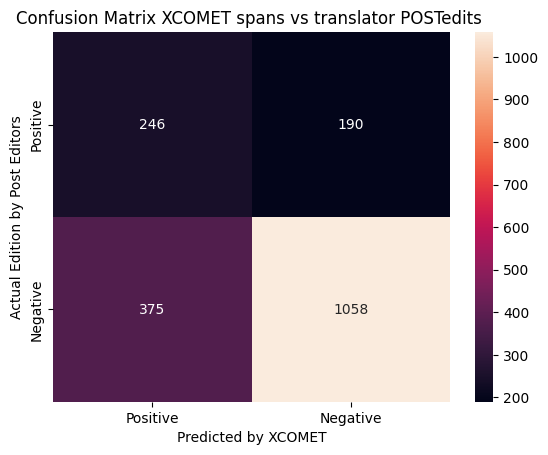

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf_matrix = np.array([[tp, fp],
                        [fn, tn]])

labels = ['Positive', 'Negative']

sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted by XCOMET')
plt.ylabel('Actual Edition by Post Editors')
plt.title('Confusion Matrix XCOMET spans vs translator POSTedits ')
plt.savefig('confusion_matrix_df_en_cz_final_with_selected_8_docs.png', dpi=300, bbox_inches='tight')  # You can change the filename and dpi as needed

plt.show()


In [42]:
precision = tp / (tp + fp)
print("precision: ", precision)
recall = tp/ (tp + fn)
print("recall: ", recall)

precision:  0.5642201834862385
recall:  0.3961352657004831


**end**